# Observing LangGraph inter-node messages (state.messages)

The self-defined learning goal of the course is exploring how to tame agent systems with regards to security, data privacy, auditing, ... the field is endless and so is the depth in each of these areas. Here we build a "lab" to peek and poke into agent systems.  

The objective is not to create an agent that models one well defined workflow/use case and excels at it, which is rated primarily by the level of usefulness. At this point, the use case is very fuzzy, yet full of room to explore: extract a TODO from a text, mind PII. Frontier models might be capable of the task using only one, single prompt. But whatever the use case, however capable the frontier models are the question remains how can we wire Personally Identifiable Information (PII) protection into an agent system?

## Focus on data flow within a graph

From an eagle eye perspective PII protection could be implemented by:

- sandboxing the system, host it in accordance with regulations, use of secure memory, ..., and cutting off the system from the outside
- filter PII from the data being processed (Inbound-Transform Pattern), then let the data flow through the system (Principle of Least Privilege)

We look at options to control the data flow because the value of agents comes from the ability to sense and react, which requires interaction with other systems. Needless to say that sandboxing is a mighty option that always should be considered to complement data flow or any other agent logic internal lines of defence. 

Filtering is a huge task on its own which can be carried out by:

- external services
- LLM nodes
- ML models
- parsers

With regards to exploring the data flow it is a side problem. 

## Graph state as a source of truth

Agent systems can grow to huge distributed system where data flows through countless APIs and sub-systems. But this is an intro course to agents and so, we focus on the state of a LangGraph graph only. Furthermore, to reduce scope, the state is considered the source of truth for the nodes communicating.  

Few options come to mind to secure the data in the state:

- filtering and masking/reduction is applied outside the graph, PII is re-inserted only when the final result is presented to the user. But what if our agent is supposed to send emails, even to unknown recipients, and we need the email to be accessible inside the graph? 

- the Inbound-Transform Pattern is applied by a node, part of the graph. In this case, the raw information is stored in the graph state - either direcly or externally 

### State handling considerations

When filtering and masking/reduction happens inside the graph, and raw data is part of the state, how to protect from other nodes:

- subgraph state isolation: processors that do not need raw data, get their own state object holding only the information needed
- state object protection and validation: for example, use Pydantic to validate state when crossing boundaries
- using dedicated, isolated channels for data flow (Isolated Mailbox) instead of using `state.messages` only

All three approaches smell like "good practice", and here we might stop the exploration for "practical reasons". Yet, you will find none of them implemented below, and of course no working agent as its all about the exploration.

## State message observation using a reducer

What stuck me looking at examples is how often intra node communication of LLM nodes goes through `state.messages` raising the question if these messages can be observed for auditing, or even manipulated for the chaos testing? 

Messages flow through the "reducer", and it can be hooked. And, it happens before messages flow from one node to another. And, the LangGraph design prevents exchanging the hook during graph execution or direct manupulation of the state circumventing the use of return to update the state. Things a node can still do  with `state.messages` are:

 - create duplicate message id which cause LangGraph to drop and replace previous messages with the same id
 - send removal messages which LangGraph will execute

None of this is covered in the reducer prototype, because it calls and relies on the standard LangGraph `add_messages()` reducer. But the hook hook copies selected messages into a vault. Because it lives and resides outside the graph state, the reducer and its vault cannot be manipulated by a node.

Even if a node tricks the LangGraph reducer - which is not buggy but relies on contract and your design - the hooks vault still contains copies of the original messages. Well, at least as long as the hook itself is in place...

You can use it for auditing, testing or debugging: compare your reducers unfiltered record with the state. I mentioned it above. Like LangGraphs reducer itself manipulates the message list you can do the same to create chaos. 

## Still no agent, man...

Blame me. But, well, this is about lab, exploring and lessons learned which are:

 - controlling data flow is essential to secure an agent system
 - never let the system itself gain control over the data flow
 - there is no one solution, apply your pattern catalog

Happy hacking!

# Reducer stub in action

Ultimately: the source is the truth, you can find the reducer in `src/reducer`!  

In [8]:
import sys

# See README.md - only valid for devcontainer workflow!
sys.path.insert(0, "/workspace")

from typing import Annotated, Callable

from src.reducer.base_transformer import BaseReducerTransformer

from langgraph.graph import END, START, StateGraph
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
from pydantic import BaseModel, Field
from IPython.display import Image, display
from src.reducer.reducer_session import (
    reducer_session,
    session_message_reducer
)


### State object

The state object holds the messages exchanged between LLM nodes, just as you can find it in so many tutorials. LangGraph does some housekeeping on the message list using its `langgraph.graph.message. add_messages` function, the "reducer". The default reducer is replaced with `session_message_reducer`. When starting a "session" (see below), a factory is used to build an actual reducer. If you will, it is just a dispatcher, an extra level of indirection. 

Understanding the specifics of the implementation is not needed to grasp the idea. A somewhat reasonable implementation has some caveats... 

In [9]:
class ReducerTestState(BaseModel):
    messages: Annotated[list[BaseMessage], session_message_reducer] = Field(
        default_factory=list
    )

### Reducer factory

The custom reducer was designed to support:

- use of different threads (= chats)
- multiple turns (= invoke() calls)  

and be able to persist its memory/vault for a "session" which is nothing else but multiple turns. This adds some boilerplate hidden behind a context manager. The `reducer_session` context manager needs to know the thread_id and reducer factory to use, for example, `make_transformer`. 

In [10]:
def make_transformer(get_thread_id: Callable[[], str]):
    return BaseReducerTransformer(get_thread_id=get_thread_id)

### LangGraph graph stub

I'll need PII for my project. Yet, I want to be able to pass some sensitive information to some processors so they can carry out their job, Therefore, I cannot apply the Inbound-Transformation Pattern outside the graph but will have to have it as part of it. 

Let's mock a most basic graph to see if/how we can control/audit data flow. And, maybe, protect against an LLM node that injects PII although instructed not to do so. 

Mind that the reducer is not suitable as your first line of defense, rather last line with potentially negative performance impact, in this primitive setup. 

In [11]:
def mock_pii_extract(state: ReducerTestState) -> dict:
    print("NODE: mock_pii_extract")
    return {}


def mock_llm_node(state: ReducerTestState) -> dict:
    print("NODE: mock_llm_node")
    return {
        "messages": [
            AIMessage(content="I am a helpful assistant. What's up for today?")
        ]
    }

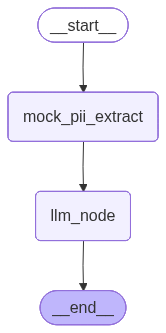

In [12]:
build_graph = StateGraph(ReducerTestState)

build_graph.add_node("llm_node", mock_llm_node)
build_graph.add_node("mock_pii_extract", mock_pii_extract)

build_graph.add_edge(START, "mock_pii_extract")
build_graph.add_edge("mock_pii_extract", "llm_node")
build_graph.add_edge("llm_node", END)

graph = build_graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

### Auditing the messages

The `reducer_session` context manager hides some of the details to handle (chat) threads, OS threads (not supported, error out), state creation and handler installation, ... to keep the notebook code comprehensive. Ignore it - it's just boilerplate.

Focus the output from the custom reducer (`BaseReducerTransformer`). A custom reducer can implement a read-only and/or a read-write callback. The `BaseReducerTransformer` implements the read-write callback to demo message injections, whereas `BaseReducerReader` does sketch the use of the read-only one. 

Notice what happens with the message `Hi! Which greeting did I use?`.

In [13]:
# To avoid session/thread leaks it is crucial to use globally unique thread IDs, and to reset them after use.
reducer = None
with reducer_session("Chat-ABC", factory=make_transformer) as session:

    print("")
    print("--- first turn ---")
    print("")

    reducer = session.reducer

    state = session.state(ReducerTestState, [HumanMessage(content="Hi! Which greeting did I use?")])
    reply = session.invoke(graph, state)

    state = ReducerTestState.model_validate(reply)
    for m in state.messages:
        if hasattr(m, "content") and isinstance(m.content, str):
            print(f"\tREPLY: {m.type}: {m.content}")

    print("")
    print("--- second turn ---")
    print("")
    
    state = session.state(ReducerTestState, [HumanMessage(content="Hello again!")])
    reply = session.invoke(graph, state)

    state = ReducerTestState.model_validate(reply)
    for m in state.messages:
        if hasattr(m, "content") and isinstance(m.content, str):
            print(f"\tREPLY: {m.type}: {m.content}")


--- first turn ---

REDUCER (thread=Chat-ABC): transforming message content: Hi! Which greeting did I use?
REDUCER (thread=Chat-ABC): replaced 'Hi' with 'Moin': Moin! Which greeting did I use?
NODE: mock_pii_extract
NODE: mock_llm_node
REDUCER (thread=Chat-ABC): transforming message content: I am a helpful assistant. What's up for today?
	REPLY: human: Moin! Which greeting did I use?
	REPLY: ai: I am a helpful assistant. What's up for today?

--- second turn ---

REDUCER (thread=Chat-ABC): transforming message content: Hello again!
NODE: mock_pii_extract
NODE: mock_llm_node
REDUCER (thread=Chat-ABC): transforming message content: I am a helpful assistant. What's up for today?
	REPLY: human: Hello again!
	REPLY: ai: I am a helpful assistant. What's up for today?


Every session has one reducer, which the caller can access. If you reference the reducer instance inside the session, it won't be destroyed automatically and you can inspect the vault.

In [14]:
print("")
print("--- vault: your audit log  ---")
print("")
vault = reducer.get_vault_for_thread("Chat-ABC")
for k, v in vault.get():
    print(f"{k}: {v}")

reducer.reset_all()


--- vault: your audit log  ---

None: content='Hi! Which greeting did I use?' additional_kwargs={} response_metadata={}
None: content='Moin! Which greeting did I use?' additional_kwargs={} response_metadata={}
None: content="I am a helpful assistant. What's up for today?" additional_kwargs={} response_metadata={} tool_calls=[] invalid_tool_calls=[]
None: content='Hello again!' additional_kwargs={} response_metadata={}
None: content="I am a helpful assistant. What's up for today?" additional_kwargs={} response_metadata={} tool_calls=[] invalid_tool_calls=[]
